Conversion de imagen con patron Moire a su version normal

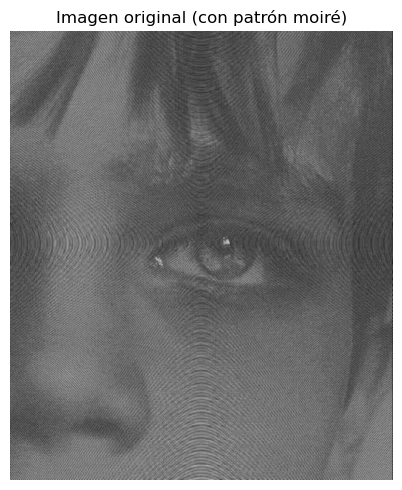

Tamaño: (785, 670, 3)


In [99]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

IMAGE_PATH = "kido.png"

img_bgr = cv2.imread(IMAGE_PATH)
if img_bgr is None:
    raise FileNotFoundError(f"No se encontró la imagen: {IMAGE_PATH}")

img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY).astype(np.float32)

plt.figure(figsize=(7, 5))
plt.imshow(img_rgb)
plt.title("Imagen original (con patrón moiré)")
plt.axis("off")
plt.tight_layout()
plt.show()
print(f"Tamaño: {img_rgb.shape}")


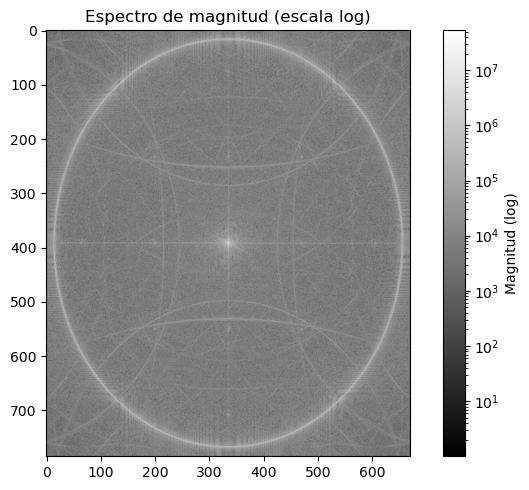

In [100]:
dft       = np.fft.fft2(img_gray)
dft_shift = np.fft.fftshift(dft)
magnitude = np.abs(dft_shift)

plt.figure(figsize=(7, 5))
plt.imshow(magnitude, norm=LogNorm(), cmap="gray")
plt.title("Espectro de magnitud (escala log)")
plt.colorbar(label="Magnitud (log)")
plt.tight_layout()
plt.show()


Picos detectados: 185


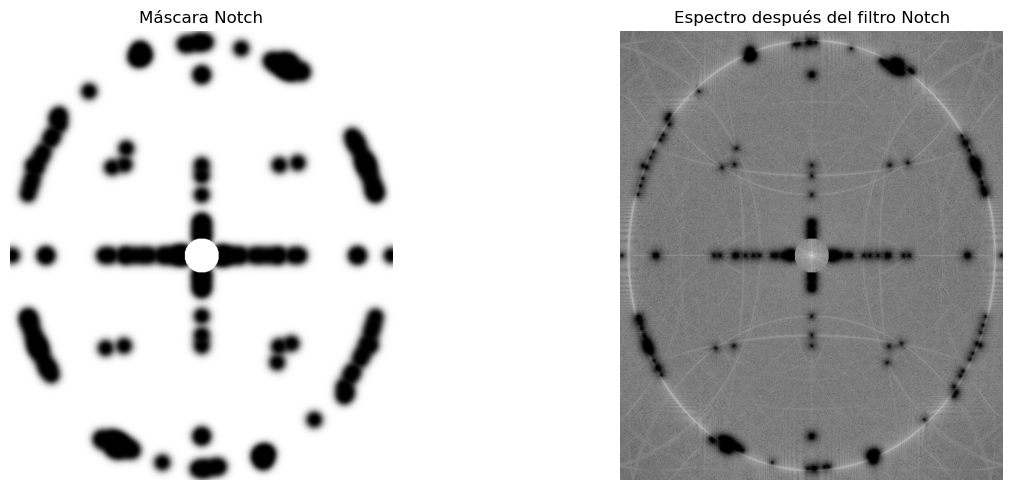

In [147]:
def build_notch_mask(magnitude, dc_radius=30, peak_thresh_factor=5.0,
                     notch_radius=22, soft_edge=True):
    rows, cols = magnitude.shape
    cy, cx = rows // 2, cols // 2
    Y, X = np.ogrid[:rows, :cols]
    dist_center = np.sqrt((X - cx)**2 + (Y - cy)**2)

    mask_search = dist_center >= dc_radius
    mag_search  = magnitude * mask_search
    threshold   = mag_search[mask_search].mean() * peak_thresh_factor

    binary_peaks = (mag_search > threshold).astype(np.uint8)
    _, _, _, centroids = cv2.connectedComponentsWithStats(binary_peaks)

    notch = np.ones((rows, cols), dtype=np.float32)
    sigma = notch_radius / 2.0

    peak_centers = [(int(round(cy_)), int(round(cx_))) for (cx_, cy_) in centroids[1:]]
    print(f"Picos detectados: {len(peak_centers)}")

    for (py, px) in peak_centers:
        for (ry, rx) in [(py, px), (2*cy - py, 2*cx - px)]:
            ry = int(np.clip(ry, 0, rows - 1))
            rx = int(np.clip(rx, 0, cols - 1))
            if soft_edge:
                d2 = (X - rx)**2 + (Y - ry)**2
                notch *= (1.0 - np.exp(-d2 / (2 * sigma**2)))
            else:
                cv2.circle(notch, (rx, ry), notch_radius, 0, -1)

    notch[dist_center < dc_radius] = 1.0
    return np.clip(notch, 0, 1)


notch_mask = build_notch_mask(magnitude,
                               dc_radius=30,
                               peak_thresh_factor=4.5,
                               notch_radius=18,
                               soft_edge=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(notch_mask, cmap="gray")
axes[0].set_title("Máscara Notch")
axes[0].axis("off")
axes[1].imshow(np.log1p(np.abs(dft_shift * notch_mask)), cmap="gray")
axes[1].set_title("Espectro después del filtro Notch")
axes[1].axis("off")
plt.tight_layout()
plt.show()


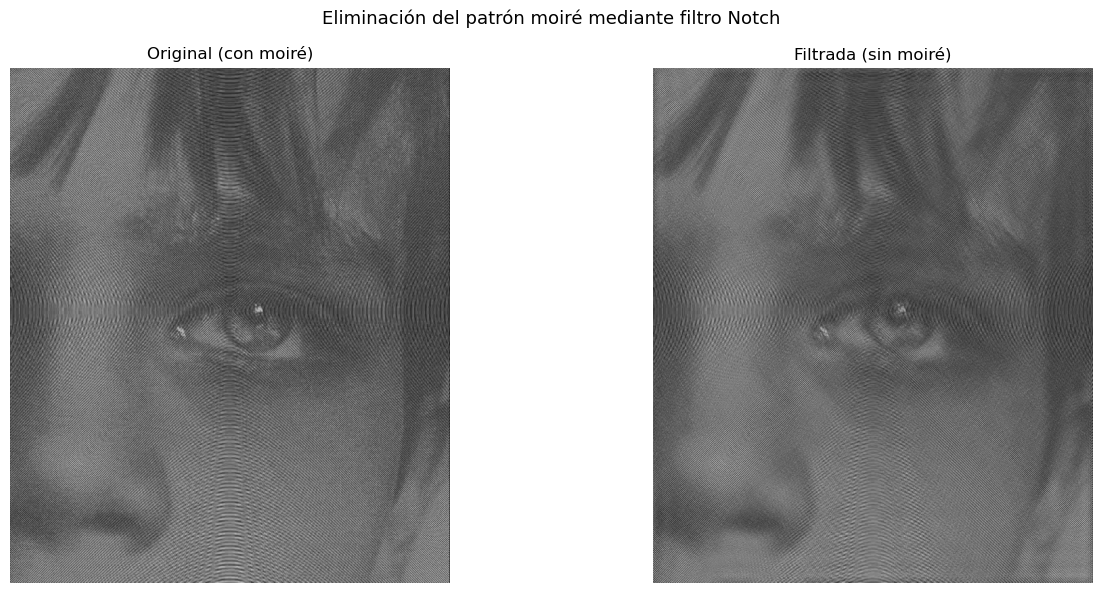

Guardado: kido_notch.png


In [148]:
def apply_mask_to_channel(channel, mask):
    dft    = np.fft.fftshift(np.fft.fft2(channel.astype(np.float32)))
    result = np.abs(np.fft.ifft2(np.fft.ifftshift(dft * mask)))
    return np.clip(result, 0, 255).astype(np.uint8)


channels_in = cv2.split(img_bgr)
notch_bgr   = cv2.merge([apply_mask_to_channel(ch, notch_mask) for ch in channels_in])
notch_rgb   = cv2.cvtColor(notch_bgr, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(img_rgb);   axes[0].set_title("Original (con moiré)"); axes[0].axis("off")
axes[1].imshow(notch_rgb); axes[1].set_title("Filtrada (sin moiré)"); axes[1].axis("off")
plt.suptitle("Eliminación del patrón moiré mediante filtro Notch", fontsize=13)
plt.tight_layout()
plt.show()

base, ext = IMAGE_PATH.rsplit(".", 1)
cv2.imwrite(f"{base}_notch.{ext}", notch_bgr)
print(f"Guardado: {base}_notch.{ext}")
